In [1]:
import os
import cv2

import numpy as np
import pandas as pd

from glob import glob
from tqdm import tqdm

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt

# Data loading

In [2]:
DATASET_PATH = "/kaggle/input/datasets/briscdataset/brisc2025/brisc2025/classification_task"

TRAIN_DIR = os.path.join(DATASET_PATH, "train")
TEST_DIR  = os.path.join(DATASET_PATH, "test")

classes = sorted(os.listdir(TRAIN_DIR))

print("Classes:")
print(classes)

Classes:
['glioma', 'meningioma', 'no_tumor', 'pituitary']


# Sample counting

In [3]:
train_counts = {}
test_counts = {}

print("TRAIN DATA DISTRIBUTION")
print("-" * 40)

for cls in classes:
    
    cls_train_path = os.path.join(TRAIN_DIR, cls)
    
    images = glob(os.path.join(cls_train_path, "*"))
    
    train_counts[cls] = len(images)
    
    print(f"{cls:15s} : {len(images)}")

print("\nTEST DATA DISTRIBUTION")
print("-" * 40)

for cls in classes:
    
    cls_test_path = os.path.join(TEST_DIR, cls)
    
    images = glob(os.path.join(cls_test_path, "*"))

    test_counts[cls] = len(images)
    
    print(f"{cls:15s} : {len(images)}")

TRAIN DATA DISTRIBUTION
----------------------------------------
glioma          : 1147
meningioma      : 1329
no_tumor        : 1067
pituitary       : 1457

TEST DATA DISTRIBUTION
----------------------------------------
glioma          : 254
meningioma      : 306
no_tumor        : 140
pituitary       : 300


# Reading the data

In [4]:
data = []

for cls in classes:
    
    cls_path = os.path.join(TRAIN_DIR, cls)
    
    image_paths = glob(os.path.join(cls_path, "*"))
    
    for img_path in image_paths:
        
        data.append([img_path, cls, "train"])

for cls in classes:
    
    cls_path = os.path.join(TEST_DIR, cls)
    
    image_paths = glob(os.path.join(cls_path, "*"))
    
    for img_path in image_paths:
        
        data.append([img_path, cls, "test"])

df = pd.DataFrame(data, columns=["image_path", "label", "source"])

print(df.head())
print("\nTotal Images :", len(df))

                                          image_path   label source
0  /kaggle/input/datasets/briscdataset/brisc2025/...  glioma  train
1  /kaggle/input/datasets/briscdataset/brisc2025/...  glioma  train
2  /kaggle/input/datasets/briscdataset/brisc2025/...  glioma  train
3  /kaggle/input/datasets/briscdataset/brisc2025/...  glioma  train
4  /kaggle/input/datasets/briscdataset/brisc2025/...  glioma  train

Total Images : 6000


# Data splitting: train, validation, and test  

In [5]:
from sklearn.model_selection import train_test_split

train_full_df = df[df["source"] == "train"].reset_index(drop=True)

train_df, val_df = train_test_split(
    train_full_df,
    test_size=0.20,
    stratify=train_full_df["label"],
    random_state=42
)

final_test_df = df[df["source"] == "test"].reset_index(drop=True)

print("TRAIN IMAGES :", len(train_df))
print("VAL IMAGES   :", len(val_df))
print("TEST IMAGES  :", len(final_test_df))

TRAIN IMAGES : 4000
VAL IMAGES   : 1000
TEST IMAGES  : 1000


In [6]:
print("TRAIN DISTRIBUTION")
print(train_df["label"].value_counts())

print("\nVAL DISTRIBUTION")
print(val_df["label"].value_counts())

print("\nTEST DISTRIBUTION")
print(final_test_df["label"].value_counts())

TRAIN DISTRIBUTION
label
pituitary     1165
meningioma    1063
glioma         918
no_tumor       854
Name: count, dtype: int64

VAL DISTRIBUTION
label
pituitary     292
meningioma    266
glioma        229
no_tumor      213
Name: count, dtype: int64

TEST DISTRIBUTION
label
meningioma    306
pituitary     300
glioma        254
no_tumor      140
Name: count, dtype: int64


# Sample visualization

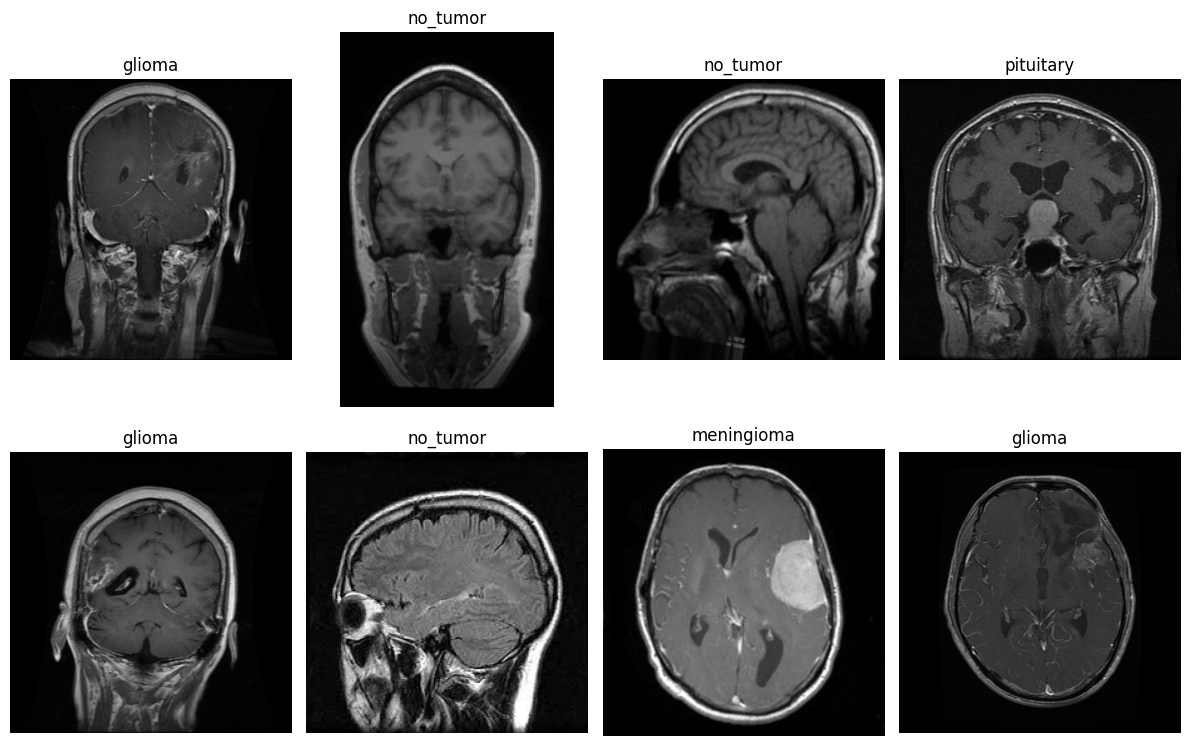

In [7]:
plt.figure(figsize=(12, 8))

for i in range(8):
    
    row = train_df.sample(1).iloc[0]
    
    img = cv2.imread(row["image_path"])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.subplot(2, 4, i+1)
    plt.imshow(img)
    plt.title(row["label"])
    plt.axis("off")

plt.tight_layout()
plt.show()

# Extracting basic features

In [8]:
def extract_features(image_path, size=(128, 128)):
    
    img = cv2.imread(image_path)
    
    img = cv2.resize(img, size)
    
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    features = []
    
    mean_rgb = rgb.mean(axis=(0,1))
    features.extend(mean_rgb)
    
    std_rgb = rgb.std(axis=(0,1))
    features.extend(std_rgb)
    
    features.append(gray.mean())
    features.append(gray.std())
    
    edges = cv2.Canny(gray, 100, 200)
    
    edge_density = np.sum(edges > 0) / edges.size
    
    features.append(edge_density)
    
    hist = cv2.calcHist([gray], [0], None, [16], [0,256])
    hist = hist.flatten()
    
    hist = hist / hist.sum()
    
    features.extend(hist)
    
    return np.array(features)

# Creating a framework to store these extracted features

In [9]:
def create_feature_dataset(dataframe):
    
    features = []
    labels = []
    
    for _, row in tqdm(dataframe.iterrows(), total=len(dataframe)):
        
        feat = extract_features(row["image_path"])
        
        features.append(feat)
        labels.append(row["label"])
    
    return np.array(features), np.array(labels)

In [10]:
X_train, y_train = create_feature_dataset(train_df)

print("Train Features Shape :", X_train.shape)
print("Train Labels Shape   :", y_train.shape)

100%|██████████| 4000/4000 [00:59<00:00, 67.26it/s]

Train Features Shape : (4000, 25)
Train Labels Shape   : (4000,)


In [11]:
print("First 5 Feature Vectors:\n")
print(X_train[:5])

print("\nFirst 5 Labels:\n")
print(y_train[:5])

First 5 Feature Vectors:

[[4.33627319e+01 4.33627319e+01 4.33627319e+01 4.66052154e+01
  4.66052154e+01 4.66052154e+01 4.33627319e+01 4.66052154e+01
  9.34448242e-02 4.95971680e-01 2.33154297e-02 3.25927734e-02
  5.91430664e-02 1.33239746e-01 1.38488770e-01 3.62548828e-02
  3.17382812e-02 2.16674805e-02 1.05590820e-02 6.71386719e-03
  5.18798828e-03 3.11279297e-03 1.58691406e-03 4.27246094e-04
  0.00000000e+00]
 [3.53939819e+01 3.53939819e+01 3.53939819e+01 4.23445196e+01
  4.23445196e+01 4.23445196e+01 3.53939819e+01 4.23445196e+01
  1.08032227e-01 5.56579590e-01 2.63061523e-02 4.11376953e-02
  8.75244141e-02 1.06811523e-01 8.72802734e-02 3.37524414e-02
  2.76489258e-02 1.93481445e-02 7.38525391e-03 3.23486328e-03
  1.64794922e-03 7.93457031e-04 4.88281250e-04 6.10351562e-05
  0.00000000e+00]
 [7.04547119e+01 7.04547119e+01 7.04547119e+01 8.30093704e+01
  8.30093704e+01 8.30093704e+01 7.04547119e+01 8.30093704e+01
  1.66687012e-01 4.50378418e-01 5.49316406e-02 3.72314453e-02
  3.4667

In [ ]:
X_val, y_val = create_feature_dataset(val_df)

print("Test Features Shape :", X_val.shape)
print("Test Labels Shape   :", y_val.shape)

In [ ]:
X_test, y_test = create_feature_dataset(final_test_df)

print("Test Features Shape :", X_test.shape)
print("Test Labels Shape   :", y_test.shape)

In [ ]:
train_features_df = pd.DataFrame(X_train)
train_features_df["label"] = y_train

val_features_df = pd.DataFrame(X_val)
val_features_df["label"] = y_val

test_features_df = pd.DataFrame(X_test)
test_features_df["label"] = y_test

train_features_df.to_csv("train_features.csv", index=False)

val_features_df.to_csv("val_features.csv", index=False)

test_features_df.to_csv("test_features.csv", index=False)


print("CSV files saved successfully!")

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_val = scaler.transform(X_val)

X_test = scaler.transform(X_test)

# Logistic Regression

In [ ]:
model = LogisticRegression(
    max_iter=50000,
    random_state=42
)

model.fit(X_train, y_train)

print("Training Completed!")

In [ ]:
val_preds = model.predict(X_val)

val_acc = accuracy_score(y_val, val_preds)

print("Validation Accuracy :", val_acc)

print("\nClassification Report\n")

print(classification_report(y_val, val_preds))

In [ ]:
test_preds = model.predict(X_test)

test_acc = accuracy_score(y_test, test_preds)

print("Test Accuracy :", test_acc)

print("\nClassification Report\n")

print(classification_report(y_test, test_preds))

In [ ]:
plt.figure(figsize=(14, 10))

sample_df = final_test_df.sample(8).reset_index(drop=True)

for i in range(8):
    
    img_path = sample_df.loc[i, "image_path"]
    true_label = sample_df.loc[i, "label"]
    
    feat = extract_features(img_path)
    feat = scaler.transform([feat])
    
    pred = model.predict(feat)[0]
    
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.subplot(2,4,i+1)
    plt.imshow(img)
    
    plt.title(f"True : {true_label}\nPred : {pred}")
    
    plt.axis("off")

plt.tight_layout()
plt.show()

# Support Vector Machine

In [ ]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel='rbf',      
    C=10,
    gamma='scale',
    probability=True,
    random_state=42
)

svm_model.fit(X_train, y_train)

print("SVM Training Completed!")

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

val_preds = svm_model.predict(X_val)

val_acc = accuracy_score(y_val, val_preds)

print("Validation Accuracy :", val_acc)

print("\nClassification Report:\n")

print(classification_report(y_val, val_preds))

In [ ]:
test_preds = svm_model.predict(X_test)

test_acc = accuracy_score(y_test, test_preds)

print("Test Accuracy :", test_acc)

print("\nClassification Report:\n")

print(classification_report(y_test, test_preds))

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, test_preds)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    criterion='gini',     
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

dt_model.fit(X_train, y_train)

print("Decision Tree Training Completed!")

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

val_preds = dt_model.predict(X_val)

val_acc = accuracy_score(y_val, val_preds)

print("Validation Accuracy :", val_acc)

print("\nClassification Report:\n")

print(classification_report(y_val, val_preds))

In [ ]:
test_preds = dt_model.predict(X_test)

test_acc = accuracy_score(y_test, test_preds)

print("Test Accuracy :", test_acc)

print("\nClassification Report:\n")

print(classification_report(y_test, test_preds))

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, test_preds)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# Random Forest 

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    random_state=42
)

rf_model.fit(X_train, y_train)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

val_preds = rf_model.predict(X_val)

val_acc = accuracy_score(y_val, val_preds)

print("Validation Accuracy :", val_acc)

print("\nClassification Report:\n")

print(classification_report(y_val, val_preds))

In [ ]:
test_preds = rf_model.predict(X_test)

test_acc = accuracy_score(y_test, test_preds)

print("Test Accuracy :", test_acc)

print("\nClassification Report:\n")

print(classification_report(y_test, test_preds))

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, test_preds)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# XG Boost

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_enc = label_encoder.fit_transform(y_train)

y_val_enc = label_encoder.transform(y_val)

y_test_enc = label_encoder.transform(y_test)

print("Classes:")
print(label_encoder.classes_)

In [ ]:
xgb_model = XGBClassifier(
    
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    
    subsample=0.8,
    colsample_bytree=0.8,
    
    objective='multi:softmax',
    
    num_class=len(classes),
    
    random_state=42,
    
    eval_metric='mlogloss'
)

xgb_model.fit(
    X_train,
    y_train_enc
)

print("XGBoost Training Completed!")

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

val_preds = xgb_model.predict(X_val)

val_acc = accuracy_score(y_val_enc, val_preds)

print("Validation Accuracy :", val_acc)

print("\nClassification Report:\n")

print(classification_report(y_val_enc, val_preds))

In [ ]:
test_preds = xgb_model.predict(X_test)

test_acc = accuracy_score(y_test_enc, test_preds)

print("Test Accuracy :", test_acc)

print("\nClassification Report:\n")

print(classification_report(y_test_enc, test_preds))

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test_enc, test_preds)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# HOG-based Feature Extraction

In [ ]:
from skimage.feature import hog

def extract_hog_features(image_path,
                         size=(128, 128),
                         orientations=9,
                         pixels_per_cell=(8, 8),
                         cells_per_block=(2, 2)):

    
    img = cv2.imread(image_path)
    
    # Resize image
    img = cv2.resize(img, size)
    
    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    hog_features = hog(
        gray,
        orientations=orientations,
        pixels_per_cell=pixels_per_cell,
        cells_per_block=cells_per_block,
        block_norm='L2-Hys',
        visualize=False,
        feature_vector=True
    )
    
    return hog_features

In [ ]:
from skimage.feature import hog
import matplotlib.pyplot as plt
import numpy as np
import cv2


def visualize_hog_directions(
    image_path,
    size=(128, 128),
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2)
):
    
    # Read image
    img = cv2.imread(image_path)
    
    # Resize
    img = cv2.resize(img, size)
    
    # Convert to RGB
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Convert to Gray
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    
    # Extract HOG Features + HOG Visualization
    hog_features, hog_image = hog(
        gray,
        orientations=orientations,
        pixels_per_cell=pixels_per_cell,
        cells_per_block=cells_per_block,
        block_norm='L2-Hys',
        visualize=True,
        feature_vector=True
    )
    
    
    # Compute Gradients
    gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    
    magnitude, angle = cv2.cartToPolar(gx, gy, angleInDegrees=True)
    
    
    # Orientation bin size
    angle_step = 180 // orientations
    
    
    # Plotting
    plt.figure(figsize=(18, 10))
    
    
    # Original Image
    plt.subplot(3, 4, 1)
    plt.imshow(rgb)
    plt.title("Original Image")
    plt.axis("off")
    
    
    # HOG Visualization
    plt.subplot(3, 4, 2)
    plt.imshow(hog_image, cmap='gray')
    plt.title("HOG Visualization")
    plt.axis("off")
    
    
    # Display Each Direction Bin
    for i in range(orientations):
        
        lower = i * angle_step
        upper = (i + 1) * angle_step
        
        
        # Create mask for this orientation
        mask = ((angle >= lower) & (angle < upper))
        
        
        # Apply mask using gradient magnitude
        direction_img = np.zeros_like(gray, dtype=np.float32)
        direction_img[mask] = magnitude[mask]
        
        
        # Normalize for visualization
        direction_img = cv2.normalize(
            direction_img,
            None,
            0,
            255,
            cv2.NORM_MINMAX
        )
        
        
        # Plot
        plt.subplot(3, 4, i + 3)
        plt.imshow(direction_img, cmap='gray')
        plt.title(f"{lower}° - {upper}°")
        plt.axis("off")
    
    
    plt.tight_layout()
    plt.show()
    
    
    return hog_features

In [ ]:
sample_path = train_df.iloc[0]["image_path"]

features = visualize_hog_directions(sample_path)

In [ ]:
sample_path = train_df.iloc[0]["image_path"]

features = extract_hog_features(sample_path)

print("HOG Feature Shape :", features.shape)
print("Total Features    :", len(features))

In [ ]:
from skimage.feature import hog
from skimage import exposure

img_path = train_df.iloc[0]["image_path"]

img = cv2.imread(img_path)

img = cv2.resize(img, (128,128))

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# HOG Visualization
features, hog_image = hog(
    gray,
    orientations=9,
    pixels_per_cell=(8,8),
    cells_per_block=(2,2),
    visualize=True,
    block_norm='L2-Hys'
)

# Better visualization
hog_image = exposure.rescale_intensity(hog_image, in_range=(0,10))

# Plot
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(gray, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(hog_image, cmap='gray')
plt.title("HOG Features")
plt.axis("off")

plt.show()

In [ ]:
def create_hog_dataset(dataframe):
    
    features = []
    labels = []
    
    for _, row in tqdm(dataframe.iterrows(),
                       total=len(dataframe)):
        
        feat = extract_hog_features(row["image_path"])
        
        features.append(feat)
        labels.append(row["label"])
    
    return np.array(features), np.array(labels)

In [ ]:
X_train, y_train = create_hog_dataset(train_df)

print("Train Shape :", X_train.shape)

In [ ]:
X_val, y_val = create_hog_dataset(val_df)

In [ ]:
X_test, y_test = create_hog_dataset(final_test_df)

print("Test Shape :", X_test.shape)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_val = scaler.transform(X_val)

X_test = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=5000,
    random_state=42
)

model.fit(X_train, y_train)

print("Training Completed!")

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

val_preds = model.predict(X_val)

val_acc = accuracy_score(y_val, val_preds)

print("Validation Accuracy :", val_acc)

print("\nClassification Report:\n")

print(classification_report(y_val, val_preds))

In [ ]:
test_preds = model.predict(X_test)

test_acc = accuracy_score(y_test, test_preds)

print("Test Accuracy :", test_acc)

print("\nClassification Report:\n")

print(classification_report(y_test, test_preds))

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, test_preds)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
plt.figure(figsize=(14,10))

sample_df = final_test_df.sample(8).reset_index(drop=True)

for i in range(8):
    
    img_path = sample_df.loc[i, "image_path"]
    
    true_label = sample_df.loc[i, "label"]
    
    # Extract HOG feature
    feat = extract_hog_features(img_path)
    
    feat = scaler.transform([feat])
    
    pred = model.predict(feat)[0]
    
    # Read image
    img = cv2.imread(img_path)
    
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.subplot(2,4,i+1)
    
    plt.imshow(img)
    
    plt.title(f"True : {true_label}\nPred : {pred}")
    
    plt.axis("off")

plt.tight_layout()

plt.show()

# LBP-based feature extraction

In [ ]:
from skimage.feature import local_binary_pattern

def extract_lbp_features(
    image_path,
    size=(128, 128),
    radius=2,
    n_points=16
):
    
    img = cv2.imread(image_path)
    
    # Resize image
    img = cv2.resize(img, size)
    
    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    lbp = local_binary_pattern(
        gray,
        P=n_points,
        R=radius,
        method="uniform"
    )
    
    
    hist, _ = np.histogram(
        lbp.ravel(),
        bins=np.arange(0, n_points + 3),
        range=(0, n_points + 2)
    )
    
    # Normalize histogram
    hist = hist.astype("float")
    hist /= (hist.sum() + 1e-6)
    
    return hist

In [ ]:
sample_path = train_df.iloc[0]["image_path"]

features = extract_lbp_features(sample_path)

print("LBP Feature Shape :", features.shape)
print("Total Features    :", len(features))
print(features)

In [ ]:
img_path = train_df.iloc[0]["image_path"]

img = cv2.imread(img_path)

img = cv2.resize(img, (128,128))

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Generate LBP
lbp = local_binary_pattern(
    gray,
    P=16,
    R=2,
    method="uniform"
)

# Plot
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(gray, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(lbp, cmap='gray')
plt.title("LBP Image")
plt.axis("off")

plt.show()

In [ ]:
def create_lbp_dataset(dataframe):
    
    features = []
    labels = []
    
    for _, row in tqdm(
        dataframe.iterrows(),
        total=len(dataframe)
    ):
        
        feat = extract_lbp_features(
            row["image_path"]
        )
        
        features.append(feat)
        labels.append(row["label"])
    
    return np.array(features), np.array(labels)

In [ ]:
X_train, y_train = create_lbp_dataset(train_df)

print("Train Shape :", X_train.shape)

In [ ]:
X_val, y_val = create_lbp_dataset(val_df)

print("Validation Shape :", X_val.shape)

In [ ]:
X_test, y_test = create_lbp_dataset(final_test_df)

print("Test Shape :", X_test.shape)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_val = scaler.transform(X_val)

X_test = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=5000,
    random_state=42
)

model.fit(X_train, y_train)

print("Training Completed!")

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

val_preds = model.predict(X_val)

val_acc = accuracy_score(y_val, val_preds)

print("Validation Accuracy :", val_acc)

print("\nClassification Report:\n")

print(classification_report(y_val, val_preds))

In [ ]:
test_preds = model.predict(X_test)

test_acc = accuracy_score(y_test, test_preds)

print("Test Accuracy :", test_acc)

print("\nClassification Report:\n")

print(classification_report(y_test, test_preds))

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, test_preds)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
plt.figure(figsize=(14,10))

sample_df = final_test_df.sample(8).reset_index(drop=True)

for i in range(8):
    
    img_path = sample_df.loc[i, "image_path"]
    
    true_label = sample_df.loc[i, "label"]
    
    # Extract feature
    feat = extract_lbp_features(img_path)
    
    feat = scaler.transform([feat])
    
    pred = model.predict(feat)[0]
    
    # Read image
    img = cv2.imread(img_path)
    
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.subplot(2,4,i+1)
    
    plt.imshow(img)
    
    plt.title(f"True : {true_label}\nPred : {pred}")
    
    plt.axis("off")

plt.tight_layout()

plt.show()

In [ ]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel='rbf',      # Radial Basis Function Kernel
    C=10,
    gamma='scale',
    probability=True,
    random_state=42
)

svm_model.fit(X_train, y_train)

print("SVM Training Completed!")


from sklearn.metrics import (
    accuracy_score,
    classification_report
)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

val_preds = svm_model.predict(X_val)

val_acc = accuracy_score(y_val, val_preds)

print("Validation Accuracy :", val_acc)

print("\nClassification Report:\n")

print(classification_report(y_val, val_preds))

In [ ]:
test_preds = svm_model.predict(X_test)

test_acc = accuracy_score(y_test, test_preds)

print("Test Accuracy :", test_acc)

print("\nClassification Report:\n")

print(classification_report(y_test, test_preds))

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, test_preds)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("SVM Confusion Matrix")

plt.show()

In [ ]:
plt.figure(figsize=(14,10))

sample_df = final_test_df.sample(8).reset_index(drop=True)

for i in range(8):
    
    img_path = sample_df.loc[i, "image_path"]
    
    true_label = sample_df.loc[i, "label"]
    
    # --------------------------------------------------------
    # Extract Features
    # --------------------------------------------------------
    
    feat = extract_glcm_features(img_path)
    
    feat = scaler.transform([feat])
    
    pred = svm_model.predict(feat)[0]
    
    # --------------------------------------------------------
    # Read Image
    # --------------------------------------------------------
    
    img = cv2.imread(img_path)
    
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.subplot(2,4,i+1)
    
    plt.imshow(img)
    
    plt.title(f"True : {true_label}\nPred : {pred}")
    
    plt.axis("off")

plt.tight_layout()

plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    criterion='gini',     # or 'entropy'
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

dt_model.fit(X_train, y_train)

print("Decision Tree Training Completed!")

from sklearn.metrics import (
    accuracy_score,
    classification_report
)

val_preds = dt_model.predict(X_val)

val_acc = accuracy_score(y_val, val_preds)

print("Validation Accuracy :", val_acc)

print("\nClassification Report:\n")

print(classification_report(y_val, val_preds))

test_preds = dt_model.predict(X_test)

test_acc = accuracy_score(y_test, test_preds)

print("Test Accuracy :", test_acc)

print("\nClassification Report:\n")

print(classification_report(y_test, test_preds))

from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, test_preds)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.title("Decision Tree Confusion Matrix")

plt.show()

plt.figure(figsize=(14,10))

sample_df = final_test_df.sample(8).reset_index(drop=True)

for i in range(8):
    
    img_path = sample_df.loc[i, "image_path"]
    
    true_label = sample_df.loc[i, "label"]
    
    feat = extract_glcm_features(img_path)
    
    feat = scaler.transform([feat])
    
    pred = dt_model.predict(feat)[0]
    
    img = cv2.imread(img_path)
    
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.subplot(2,4,i+1)
    
    plt.imshow(img)
    
    plt.title(f"True : {true_label}\nPred : {pred}")
    
    plt.axis("off")

plt.tight_layout()

plt.show()

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

val_preds = dt_model.predict(X_val)

val_acc = accuracy_score(y_val, val_preds)

print("Validation Accuracy :", val_acc)

print("\nClassification Report:\n")

print(classification_report(y_val, val_preds))

test_preds = dt_model.predict(X_test)

test_acc = accuracy_score(y_test, test_preds)

print("Test Accuracy :", test_acc)

print("\nClassification Report:\n")

print(classification_report(y_test, test_preds))

from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, test_preds)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.title("Decision Tree Confusion Matrix")

plt.show()

plt.figure(figsize=(14,10))

sample_df = final_test_df.sample(8).reset_index(drop=True)

for i in range(8):
    
    img_path = sample_df.loc[i, "image_path"]
    
    true_label = sample_df.loc[i, "label"]
    
    feat = extract_glcm_features(img_path)
    
    feat = scaler.transform([feat])
    
    pred = dt_model.predict(feat)[0]
    
    img = cv2.imread(img_path)
    
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.subplot(2,4,i+1)
    
    plt.imshow(img)
    
    plt.title(f"True : {true_label}\nPred : {pred}")
    
    plt.axis("off")

plt.tight_layout()

plt.show()

In [ ]:
test_preds = dt_model.predict(X_test)

test_acc = accuracy_score(y_test, test_preds)

print("Test Accuracy :", test_acc)

print("\nClassification Report:\n")

print(classification_report(y_test, test_preds))

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, test_preds)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.title("Decision Tree Confusion Matrix")

plt.show()

In [ ]:
plt.figure(figsize=(14,10))

sample_df = final_test_df.sample(8).reset_index(drop=True)

for i in range(8):
    
    img_path = sample_df.loc[i, "image_path"]
    
    true_label = sample_df.loc[i, "label"]
    
    feat = extract_glcm_features(img_path)
    
    feat = scaler.transform([feat])
    
    pred = dt_model.predict(feat)[0]
    
    img = cv2.imread(img_path)
    
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.subplot(2,4,i+1)
    
    plt.imshow(img)
    
    plt.title(f"True : {true_label}\nPred : {pred}")
    
    plt.axis("off")

plt.tight_layout()

plt.show()

In [ ]:
from sklearn import tree

plt.figure(figsize=(20,10))

tree.plot_tree(
    dt_model,
    filled=True,
    fontsize=8,
    class_names=classes
)

plt.title("Decision Tree Visualization")

plt.show()

In [ ]:
importance = dt_model.feature_importances_

plt.figure(figsize=(12,5))

plt.bar(
    range(len(importance)),
    importance
)

plt.xlabel("Feature Index")

plt.ylabel("Importance Score")

plt.title("GLCM Feature Importance")

plt.show()

In [ ]:
feature_names = [
    "contrast_mean",
    "contrast_std",
    
    "dissimilarity_mean",
    "dissimilarity_std",
    
    "homogeneity_mean",
    "homogeneity_std",
    
    "energy_mean",
    "energy_std",
    
    "correlation_mean",
    "correlation_std",
    
    "ASM_mean",
    "ASM_std"
]

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df)

In [ ]:
DecisionTreeClassifier(
    criterion='entropy',
    max_depth=20,
    min_samples_split=3
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    random_state=42
)

rf_model.fit(X_train, y_train)

preds = rf_model.predict(X_test)

acc = accuracy_score(y_test, preds)

print("Random Forest Accuracy :", acc)

In [ ]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()

nb_model.fit(X_train, y_train)

print("Naive Bayes Training Completed!")

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

val_preds = nb_model.predict(X_val)

val_acc = accuracy_score(y_val, val_preds)

print("Validation Accuracy :", val_acc)

print("\nClassification Report:\n")

print(classification_report(y_val, val_preds))

In [ ]:
test_preds = nb_model.predict(X_test)

test_acc = accuracy_score(y_test, test_preds)

print("Test Accuracy :", test_acc)

print("\nClassification Report:\n")

print(classification_report(y_test, test_preds))

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, test_preds)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.title("Naive Bayes Confusion Matrix")

plt.show()

In [ ]:
sample_probs = nb_model.predict_proba(X_test[:5])

print(sample_probs)

In [ ]:
sample = X_test[0].reshape(1, -1)

probs = nb_model.predict_proba(sample)[0]

plt.figure(figsize=(8,4))

plt.bar(classes, probs)

plt.ylabel("Probability")

plt.title("Naive Bayes Prediction Confidence")

plt.xticks(rotation=20)

plt.show()

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_enc = label_encoder.fit_transform(y_train)

y_val_enc = label_encoder.transform(y_val)

y_test_enc = label_encoder.transform(y_test)

print("Classes:")
print(label_encoder.classes_)

xgb_model = XGBClassifier(
    
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    
    subsample=0.8,
    colsample_bytree=0.8,
    
    objective='multi:softmax',
    
    num_class=len(classes),
    
    random_state=42,
    
    eval_metric='mlogloss'
)

xgb_model.fit(
    X_train,
    y_train_enc
)

print("XGBoost Training Completed!")

from sklearn.metrics import (
    accuracy_score,
    classification_report
)

val_preds = xgb_model.predict(X_val)

val_acc = accuracy_score(y_val_enc, val_preds)

print("Validation Accuracy :", val_acc)

print("\nClassification Report:\n")

print(
    classification_report(
        y_val_enc,
        val_preds,
        target_names=classes
    )
)

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_enc = label_encoder.fit_transform(y_train)

y_val_enc = label_encoder.transform(y_val)

y_test_enc = label_encoder.transform(y_test)

print("Classes:")
print(label_encoder.classes_)

In [ ]:
xgb_model = XGBClassifier(
    
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    
    subsample=0.8,
    colsample_bytree=0.8,
    
    objective='multi:softmax',
    
    num_class=len(classes),
    
    random_state=42,
    
    eval_metric='mlogloss'
)

xgb_model.fit(
    X_train,
    y_train_enc
)

print("XGBoost Training Completed!")

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

val_preds = xgb_model.predict(X_val)

val_acc = accuracy_score(y_val_enc, val_preds)

print("Validation Accuracy :", val_acc)

print("\nClassification Report:\n")

print(
    classification_report(
        y_val_enc,
        val_preds,
        target_names=classes
    )
)

In [ ]:
test_preds = xgb_model.predict(X_test)

test_acc = accuracy_score(y_test_enc, test_preds)

print("Test Accuracy :", test_acc)

print("\nClassification Report:\n")

print(
    classification_report(
        y_test_enc,
        test_preds,
        target_names=classes
    )
)

In [ ]:
importance = xgb_model.feature_importances_

feature_names = [
    "contrast_mean",
    "contrast_std",
    
    "dissimilarity_mean",
    "dissimilarity_std",
    
    "homogeneity_mean",
    "homogeneity_std",
    
    "energy_mean",
    "energy_std",
    
    "correlation_mean",
    "correlation_std",
    
    "ASM_mean",
    "ASM_std"
]

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df)

In [ ]:
importance_df.plot(
    x='Feature',
    y='Importance',
    kind='bar',
    figsize=(10,5)
)

plt.title("XGBoost Feature Importance")

plt.ylabel("Importance Score")

plt.xticks(rotation=45)

plt.show()

In [ ]:
probs = xgb_model.predict_proba(X_test[:5])
print(probs)